# GR-Prediction Eval - Discretized LSTM (Ableton Ideal Compressor)

Evaluates the CREPE-style discretized frame-rate LSTM trained by `train_lstm_nocond_discretized_ableton.ipynb`.

This notebook is adapted from `eval_lstm_discretized.ipynb`, but selects Ableton runs and reads wet files from `Diff-SSL-G-Comp/ableton_compressed/` instead of `processed_ground_truth/<setting>/`.

Features:
- List and select Ableton discretized LSTM runs
- Load best or last checkpoint plus `hparams.json`
- Predict gain-reduction curves from dry audio
- Compare against target GR computed from dry/wet Ableton files
- Plot dry waveform, target vs prediction, error, and bin probability heatmap


In [1]:
# -- 0. Imports and defaults ------------------------------------------

import os, glob, json, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import lightning as pl

warnings.filterwarnings("ignore", category=UserWarning)

try:
    from src.dsp_torch import (
        GR_DB_MIN, GR_DB_MAX, RMS_WINDOW,
        gain_reduction_db,
    )
    from src import dsp_torch
    print(f"Shared GR DSP helpers: {dsp_torch.__file__}")
except Exception as exc:
    dsp_torch = None
    GR_DB_MIN = -30.0
    GR_DB_MAX = 0.0
    RMS_WINDOW = 1024

    def windowed_rms(signal: torch.Tensor, window_size: int) -> torch.Tensor:
        orig_ndim = signal.ndim
        if orig_ndim == 1:
            sig = signal.view(1, 1, -1)
        elif orig_ndim == 2:
            sig = signal.unsqueeze(0)
        elif orig_ndim == 3:
            sig = signal
        else:
            raise ValueError(f"windowed_rms expects 1/2/3-D input, got {orig_ndim}-D")

        batch, channels, frames = sig.shape
        sq = sig.reshape(batch * channels, 1, frames) ** 2
        kernel = torch.ones(1, 1, window_size, device=sig.device, dtype=sq.dtype) / window_size
        rms_sq = F.conv1d(sq, kernel, padding=window_size - 1)[..., :frames]
        rms = torch.sqrt(rms_sq.clamp(min=1e-10)).reshape(batch, channels, frames)

        if orig_ndim == 1:
            return rms.view(-1)
        if orig_ndim == 2:
            return rms.squeeze(0)
        return rms

    def gain_reduction_db(dry: torch.Tensor, wet: torch.Tensor, window_size: int = RMS_WINDOW) -> torch.Tensor:
        dry_rms = windowed_rms(dry, window_size)
        wet_rms = windowed_rms(wet, window_size)
        return 20 * torch.log10(wet_rms) - 20 * torch.log10(dry_rms)

    print(f"Using self-contained GR DSP helpers because src.dsp_torch could not be imported: {exc}")

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs"

SETTING = "ableton_compressed"
DATASET_NAME = "ableton_ideal_compressor"
RUN_TAG_FILTER = "ableton"
# Set SELECTED_RUN_NAME in the run-selection cell after available runs are listed.

SAMPLE_RATE = 44100
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


from eval_helpers import _checkpoint_sort_key, latest_best_checkpoint, list_runs


print(f"torch {torch.__version__} | device: {DEVICE}")
print(f"DATA_ROOT: {DATA_ROOT}")
print(f"RUNS_DIR : {RUNS_DIR}")


/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shared GR DSP helpers: /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/src/dsp_torch.py
torch 2.10.0 | device: cpu
DATA_ROOT: /Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp
RUNS_DIR : /Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs


In [2]:
# -- 1. List available Ableton discretized LSTM runs ------------------

assert RUNS_DIR and os.path.isdir(RUNS_DIR), f"RUNS_DIR not found: {RUNS_DIR}"

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, "No runs found yet."

available_models_df = runs_df[
    (runs_df["type"] == "frame_rate_lstm_discretized")
    & (
        runs_df["run"].str.contains(RUN_TAG_FILTER, case=False, na=False)
        | (runs_df["setting"] == SETTING)
        | (runs_df["dataset"] == DATASET_NAME)
    )
].copy()
assert not available_models_df.empty, (
    "No Ableton discretized LSTM runs found. Check that the training notebook "
    "saved hparams.json with setting='ableton_compressed'."
)

display_cols = ["run", "type", "setting", "dataset", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available Ableton discretized LSTM runs: {len(available_models_df)}")
display(available_models_df[display_cols])


Selected run   : lstm_gr_20260524_140754_lstm_v3_discretized_ableton
Model type     : frame_rate_lstm_discretized
Setting        : ableton_compressed
Dataset        : ableton_ideal_compressor
Eval checkpoint: best-110-31413.ckpt
Best val loss  : 0.051945


,run,type,setting,dataset,epoch,best_val,n_ckpts,eval_ckpt,modified
1,tcn_gr_20260418_104238,?,?,?,NaN,NaN,0,None,2026-05-24 11:43:10.365531445
2,tcn_gr_20260418_112110,?,?,?,NaN,NaN,0,None,2026-05-24 11:43:10.389226198
3,tcn_gr_20260418_114042,?,?,?,NaN,NaN,0,None,2026-05-24 11:43:10.411942959
4,tcn_gr_20260418_115107,?,?,?,NaN,NaN,0,None,2026-05-24 11:43:10.433717012
5,tcn_gr_20260418_115407,?,?,?,96.0,0.002399,23,best-096-8439.ckpt,2026-05-24 11:43:10.503089666
6,tcn_gr_20260418_125431_rf1_5s_n14_d2,?,?,?,NaN,NaN,25,best-097-4312.ckpt,2026-05-24 11:43:10.600898027
7,tcn_gr_20260418_135645_rf2_7s_n10_d3,?,?,?,105.0,0.028991,25,best-105-4664.ckpt,2026-05-24 11:43:10.718323469
8,tcn_gr_20260418_143050_no_batch_norm,?,?,?,130.0,0.034938,30,best-021-968.ckpt,2026-05-24 11:43:10.857748508
9,tcn_gr_20260426_093002_with_recommendations,?,threshold_-4_attack_1_release_0.4_ratio_10,?,230.0,0.023034,52,best-228-9847.ckpt,2026-05-24 11:43:10.925353050
10,tcn_gr_20260427_094122_with_recommendations_h100,?,threshold_-4_attack_1_release_0.4_ratio_10,?,427.0,0.024866,89,best-426-18361.ckpt,2026-05-24 11:43:11.050783634


In [ ]:
# -- 2. Select run and checkpoint -------------------------------------

SELECTED_RUN_NAME = "lstm_gr_20260524_140754_lstm_v3_discretized_ableton"

matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
assert len(matches) == 1, f"Run not found in available Ableton runs: {SELECTED_RUN_NAME}"
selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

print(f"Selected run   : {RUN_NAME}")
print(f"Model type     : {selected_run['type']}")
print(f"Setting        : {selected_run['setting']}")
print(f"Dataset        : {selected_run['dataset']}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")

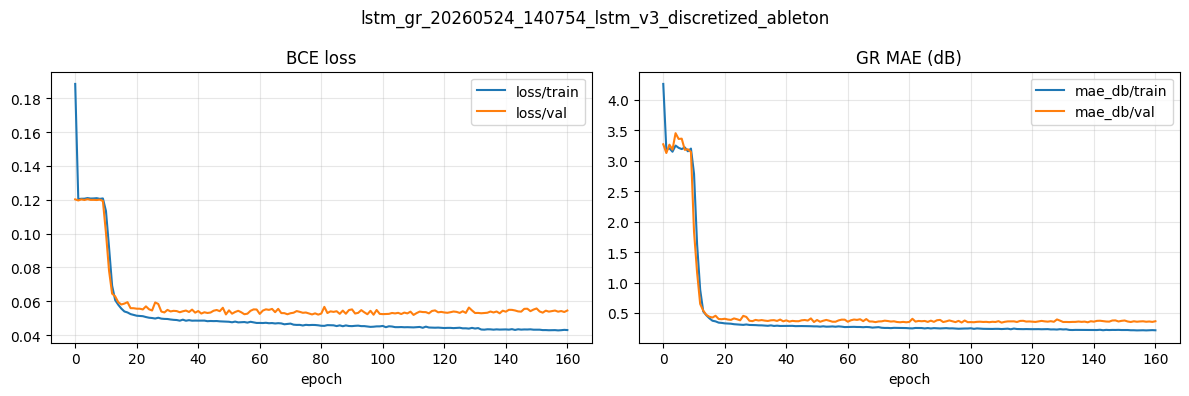

In [3]:
# -- 2. Plot training curves ------------------------------------------

def plot_training_curves(run_dir=RUN_DIR):
    csv_path = Path(run_dir) / "csv" / "metrics.csv"
    if not csv_path.is_file():
        print(f"No CSV metrics found at {csv_path}")
        return None

    df = pd.read_csv(csv_path)
    if "epoch" not in df.columns:
        print("metrics.csv has no epoch column")
        return df

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for col in ("loss/train", "loss/val"):
        if col in df.columns:
            d = df[["epoch", col]].dropna()
            if not d.empty:
                axes[0].plot(d["epoch"], d[col], label=col)
    axes[0].set_title("BCE loss")
    axes[0].set_xlabel("epoch")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    for col in ("mae_db/train", "mae_db/val"):
        if col in df.columns:
            d = df[["epoch", col]].dropna()
            if not d.empty:
                axes[1].plot(d["epoch"], d[col], label=col)
    axes[1].set_title("GR MAE (dB)")
    axes[1].set_xlabel("epoch")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.suptitle(Path(run_dir).name)
    fig.tight_layout()
    plt.show()
    return df


from eval_helpers import plot_loss_curves

metrics_df = plot_loss_curves(RUN_DIR)


In [4]:
# -- 3. Model definitions and checkpoint loading ----------------------

GR_NUM_BINS = 151
GR_BIN_RESOLUTION = 0.2
GR_BIN_CENTERS = torch.linspace(GR_DB_MIN, GR_DB_MAX, GR_NUM_BINS)


def logits_to_local_avg_db(logits, window=5):
    probs = torch.sigmoid(logits)
    centers = GR_BIN_CENTERS.to(logits.device)
    peak = probs.argmax(dim=1)
    B, N, T = probs.shape
    bin_idx = torch.arange(N, device=logits.device).view(1, N, 1).expand(B, N, T)
    lo = (peak.unsqueeze(1) - window).clamp(min=0)
    hi = (peak.unsqueeze(1) + window + 1).clamp(max=N)
    mask = (bin_idx >= lo) & (bin_idx < hi)
    masked_probs = probs * mask
    weighted = (masked_probs * centers[None, :, None]).sum(dim=1, keepdim=True)
    total = masked_probs.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return weighted / total


class FrameRateLSTMGR(nn.Module):
    def __init__(self, hop_size=256, encoder_channels=32, hidden_size=64,
                 num_layers=2, dropout=0.0, num_bins=GR_NUM_BINS):
        super().__init__()
        self.hop_size = hop_size
        self.num_bins = num_bins
        self.rf = hop_size * 4
        ks = hop_size * 2
        self.encoder = nn.Sequential(
            nn.Conv1d(1, encoder_channels, ks, stride=hop_size, padding=ks // 2),
            nn.PReLU(encoder_channels),
            nn.Conv1d(encoder_channels, encoder_channels, 3, padding=1),
            nn.PReLU(encoder_channels),
        )
        self.lstm = nn.LSTM(
            encoder_channels, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, num_bins),
        )

    def forward(self, x):
        feat = self.encoder(x)
        feat = feat.transpose(1, 2)
        h, _ = self.lstm(feat)
        logits = self.head(h)
        return logits.transpose(1, 2)

    def to_db(self, logits, T=None):
        db = logits_to_local_avg_db(logits)
        if T is not None:
            db = F.interpolate(db, size=T, mode="linear", align_corners=False)
        return db

    def reset_states(self):
        pass


class GRPredictionLSTM(pl.LightningModule):
    def __init__(self, model, lr=1e-3, sigma_bins=2.0, warmup_frames=4,
                 lr_patience=20, min_lr=1e-6):
        super().__init__()
        self.model = model
        self.lr = lr
        self.sigma_bins = sigma_bins
        self.warmup_frames = warmup_frames
        self.lr_patience = lr_patience
        self.min_lr = min_lr

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=self.lr_patience, min_lr=self.min_lr,
        )
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "monitor": "loss/val"}}


from eval_helpers import _find_hparams_json


def build_lstm_from_hparams(hp):
    h = hp["lstm"]
    d = hp.get("discretization", {})
    return FrameRateLSTMGR(
        hop_size=h["hop_size"],
        encoder_channels=h["encoder_channels"],
        hidden_size=h["hidden_size"],
        num_layers=h["num_layers"],
        dropout=h.get("dropout", 0.0),
        num_bins=d.get("num_bins", GR_NUM_BINS),
    )


def load_system_from_ckpt(ckpt_path, hparams_path=None):
    if hparams_path is None:
        hparams_path = _find_hparams_json(ckpt_path)
    assert hparams_path and os.path.isfile(hparams_path), f"hparams.json not found near {ckpt_path}"
    with open(hparams_path) as f:
        hp = json.load(f)

    expected_hash = hp.get("src_dsp_torch_sha256")
    if dsp_torch is not None and expected_hash and re.fullmatch(r"[0-9a-f]{64}", expected_hash):
        import hashlib as _hl
        local_hash = _hl.sha256(Path(dsp_torch.__file__).read_bytes()).hexdigest()
        if local_hash != expected_hash:
            print("[warning] local src.dsp_torch differs from checkpoint's version")

    model = build_lstm_from_hparams(hp)
    loss_hp = hp.get("loss", {})
    system = GRPredictionLSTM.load_from_checkpoint(
        ckpt_path, model=model, map_location=DEVICE,
        lr=hp.get("lr", 1e-3),
        sigma_bins=loss_hp.get("sigma_bins", 2.0),
        warmup_frames=loss_hp.get("warmup_frames", 4),
        lr_patience=hp.get("lr_plateau_patience", 20),
        min_lr=hp.get("min_lr", 1e-6),
    )
    system.to(DEVICE)
    system.eval()
    return system, hp


print("Model builder registered: frame_rate_lstm_discretized")


Model builder registered: frame_rate_lstm_discretized


In [5]:
# -- 4. Ableton pair discovery, prediction, and plotting ---------------

def wet_dir_for_setting(data_root, setting):
    candidates = []
    if setting == SETTING:
        candidates.append(os.path.join(data_root, setting))
    candidates.append(os.path.join(data_root, "processed_ground_truth", setting))
    candidates.append(os.path.join(data_root, setting))

    for candidate in candidates:
        if os.path.isdir(candidate):
            return candidate
    raise FileNotFoundError(f"No wet directory found for setting={setting}. Tried: {candidates}")


def _song_from_wet_path(wet_path):
    name = os.path.basename(wet_path)
    if name.endswith("-exported.wav"):
        return name.replace("-exported.wav", "")

    stem = Path(name).stem

    # Ableton exports are named like:
    #   Bounce 12-AncoraQui_UnmasteredWAV [2026-05-20 170849]-1.wav
    # Normalize that back to the dry-song key: AncoraQui.
    m = re.match(r"^Bounce\s+\d+-(.+?)_UnmasteredWAV(?:\s+\[.*\])?(?:-\d+)?$", stem)
    if m:
        return m.group(1)

    if "_UnmasteredWAV" in stem:
        return stem.split("_UnmasteredWAV", 1)[0]
    return stem


def same_setting_pairs(data_root, setting):
    dry_dir = os.path.join(data_root, "processed_normalized")
    wet_dir = wet_dir_for_setting(data_root, setting)
    assert os.path.isdir(dry_dir), f"Missing: {dry_dir}"
    assert os.path.isdir(wet_dir), f"Missing: {wet_dir}"

    dry_lookup = {
        os.path.basename(p).replace("_UnmasteredWAV.wav", ""): p
        for p in sorted(glob.glob(os.path.join(dry_dir, "*_UnmasteredWAV.wav")))
    }

    wet_paths = sorted(glob.glob(os.path.join(wet_dir, "*.wav")))
    pairs = []
    unmatched = []
    for wet_path in wet_paths:
        song = _song_from_wet_path(wet_path)
        if song in dry_lookup:
            pairs.append((dry_lookup[song], wet_path))
        else:
            unmatched.append((song, os.path.basename(wet_path)))

    if not pairs:
        preview = unmatched[:10]
        raise AssertionError(
            f"No dry/wet pairs for setting={setting} using wet_dir={wet_dir}. "
            f"Dry examples={list(dry_lookup)[:10]}; parsed wet examples={preview}"
        )
    if unmatched:
        print(f"Matched {len(pairs)} wet files; skipped {len(unmatched)} without dry match.")
    return pairs


from eval_helpers import _read_dry_wet_segment, same_setting_pairs, wet_dir_for_setting


@torch.no_grad()
def predict_gr_curves(
    ckpt_path,
    dry_wav_path,
    wet_wav_path,
    start_sec=0.0,
    duration_sec=6.0,
    hparams_path=None,
    pre_roll_sec=None,
):
    system, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    sr = int(hp["sample_rate"])
    rms_win = int(hp["rms_window"])
    hop = hp["lstm"]["hop_size"]
    rf_samples = hop * 4

    start = int(round(start_sec * sr))
    stop = start + int(round(duration_sec * sr))
    pre_roll = rf_samples if pre_roll_sec is None else int(round(pre_roll_sec * sr))
    context_start = max(0, start - pre_roll)
    context_offset = start - context_start

    dry, wet = _read_dry_wet_segment(dry_wav_path, wet_wav_path, context_start, stop, sr)

    gr_target_db = gain_reduction_db(
        dry.unsqueeze(0), wet.unsqueeze(0), rms_win
    ).squeeze(0).clamp(GR_DB_MIN, GR_DB_MAX)

    x = dry.unsqueeze(0).to(DEVICE)
    if hasattr(system.model, "reset_states"):
        system.model.reset_states()
    logits = system(x)
    gr_pred_db = system.model.to_db(logits, T=dry.shape[-1]).squeeze(0)

    n = min(
        stop - start,
        dry.shape[-1] - context_offset,
        gr_target_db.shape[-1] - context_offset,
        gr_pred_db.shape[-1] - context_offset,
    )
    assert n > 0
    w = slice(context_offset, context_offset + n)

    gr_true = gr_target_db[..., w].squeeze().cpu().numpy()
    gr_pred = gr_pred_db[..., w].squeeze().cpu().numpy()
    dry_wave = dry[..., w].squeeze().cpu().numpy()

    probs_full = torch.sigmoid(logits).squeeze(0).cpu()
    frame_start = context_offset // hop
    frame_end = min((context_offset + n) // hop + 1, probs_full.shape[1])
    bin_probs = probs_full[:, frame_start:frame_end].numpy()

    err = gr_pred - gr_true
    song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")

    return {
        "song": song,
        "setting": hp.get("setting", SETTING),
        "dataset": hp.get("dataset", DATASET_NAME),
        "model_type": hp.get("model_type", "frame_rate_lstm_discretized"),
        "ckpt": ckpt_path,
        "sample_rate": sr,
        "start_sec": start_sec,
        "duration_sec": n / sr,
        "pre_roll_sec": context_offset / sr,
        "time": np.arange(n) / sr,
        "dry": dry_wave,
        "gr_true": gr_true,
        "gr_pred": gr_pred,
        "error": err,
        "mae_db": float(np.mean(np.abs(err))),
        "rmse_db": float(np.sqrt(np.mean(err ** 2))),
        "bin_probs": bin_probs,
        "hop_size": hop,
        "hparams": hp,
    }


@torch.no_grad()
def visualize_prediction(
    ckpt_path,
    dry_wav_path=None,
    wet_wav_path=None,
    start_sec=0.0,
    duration_sec=6.0,
    hparams_path=None,
    pre_roll_sec=None,
    title=None,
    show_heatmap=True,
):
    _, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    setting = hp.get("setting", SETTING)
    pairs = same_setting_pairs(DATA_ROOT, setting)

    if dry_wav_path is None:
        dry_wav_path, wet_wav_path = pairs[0]
    elif wet_wav_path is None:
        song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")
        wet_dir = wet_dir_for_setting(DATA_ROOT, setting)
        candidates = [
            os.path.join(wet_dir, f"{song}-exported.wav"),
            os.path.join(wet_dir, f"{song}.wav"),
        ]
        wet_wav_path = next((p for p in candidates if os.path.isfile(p)), None)
        assert wet_wav_path is not None, f"No wet WAV found for {song}. Tried: {candidates}"

    curves = predict_gr_curves(
        ckpt_path=ckpt_path,
        dry_wav_path=dry_wav_path,
        wet_wav_path=wet_wav_path,
        start_sec=start_sec,
        duration_sec=duration_sec,
        hparams_path=hparams_path,
        pre_roll_sec=pre_roll_sec,
    )

    t = curves["time"]
    n_rows = 4 if show_heatmap else 3
    ratios = [1, 2, 1, 2] if show_heatmap else [1, 2, 1]
    fig, axes = plt.subplots(
        n_rows, 1, figsize=(11, 3 * n_rows - 2), sharex=True,
        gridspec_kw={"height_ratios": ratios},
    )

    axes[0].plot(t, curves["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry")
    axes[0].set_ylim(-1.05, 1.05)
    axes[0].grid(alpha=0.3)

    axes[1].plot(t, curves["gr_true"], label="target", lw=1.4, color="#1f77b4")
    axes[1].plot(t, curves["gr_pred"], label="prediction", lw=1.2, color="#d62728", alpha=0.85)
    axes[1].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[1].set_ylabel("GR (dB)")
    axes[1].set_ylim(GR_DB_MIN - 1, 1)
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

    axes[2].plot(t, curves["error"], lw=0.9, color="#9467bd")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("error (dB)")
    axes[2].grid(alpha=0.3)

    if show_heatmap:
        probs = curves["bin_probs"]
        extent = [t[0], t[-1], GR_DB_MIN, GR_DB_MAX]
        im = axes[3].imshow(
            probs,
            origin="lower",
            aspect="auto",
            extent=extent,
            cmap="magma",
            vmin=0.0,
            vmax=max(0.1, float(np.percentile(probs, 99))),
        )
        axes[3].set_ylabel("bin center (dB)")
        axes[3].set_ylim(GR_DB_MIN, GR_DB_MAX)
        fig.colorbar(im, ax=axes[3], label="P(bin)", shrink=0.8)

    axes[-1].set_xlabel("time (s)")

    ttl = title or (
        f"{curves['song']} | Ableton ideal compressor | {curves['setting']}\n"
        f"ckpt={os.path.basename(ckpt_path)} "
        f"pre-roll={curves['pre_roll_sec']:.2f}s "
        f"MAE={curves['mae_db']:.2f} dB RMSE={curves['rmse_db']:.2f} dB"
    )
    fig.suptitle(ttl, y=0.995)
    fig.tight_layout()
    plt.show()
    return curves


def compare_same_setting_curves(
    ckpt_path,
    start_sec=20.0,
    duration_sec=6.0,
    max_pairs=3,
    start_pair=0,
    hparams_path=None,
    show_heatmap=True,
):
    _, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    pairs = same_setting_pairs(DATA_ROOT, hp.get("setting", SETTING))
    selected = pairs[start_pair:max_pairs + start_pair]
    print(f"Comparing {len(selected)} of {len(pairs)} pairs")
    return [
        visualize_prediction(
            ckpt_path=ckpt_path,
            dry_wav_path=d,
            wet_wav_path=w,
            start_sec=start_sec,
            duration_sec=duration_sec,
            hparams_path=hparams_path,
            show_heatmap=show_heatmap,
        )
        for d, w in selected
    ]


pairs = same_setting_pairs(DATA_ROOT, SETTING)
print(f"Found {len(pairs)} Ableton dry/wet pair(s)")
print("First pair:")
print("  dry:", pairs[0][0])
print("  wet:", pairs[0][1])


Found 60 Ableton dry/wet pair(s)
First pair:
  dry: /Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp/processed_normalized/5thFloor_UnmasteredWAV.wav
  wet: /Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp/ableton_compressed/Bounce 1-5thFloor_UnmasteredWAV [2026-05-20 170849]-1.wav


## Usage

Run the cells below after training has synced a checkpoint into `RUNS_DIR`. Use the available-runs cell first, then set `SELECTED_RUN_NAME` in the following selection cell.

Use `show_heatmap=False` to hide the bin probability panel.


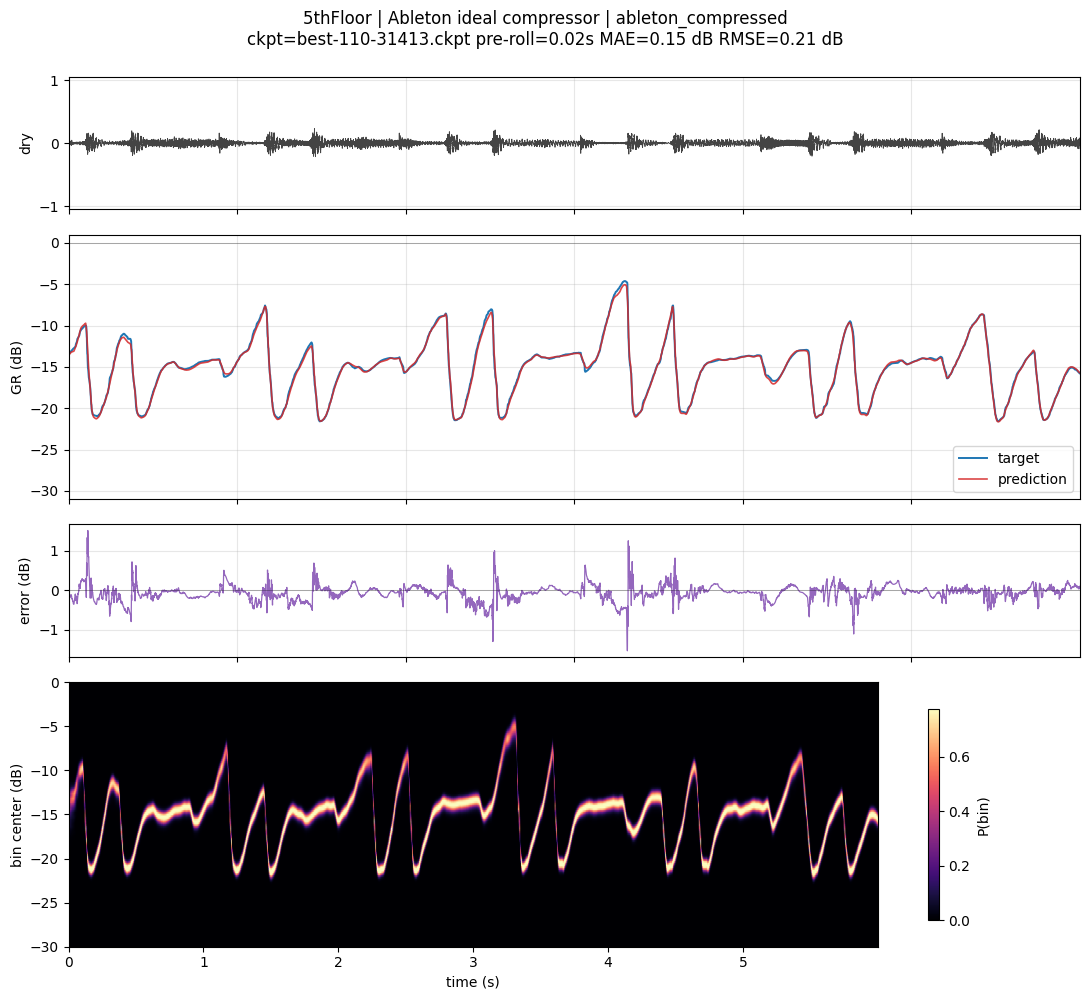

In [6]:
# Visualize one song
curves = visualize_prediction(
    ckpt_path=EVAL_CKPT_PATH,
    start_sec=20.0,
    duration_sec=6.0,
    show_heatmap=True,
)


Comparing 3 of 60 pairs


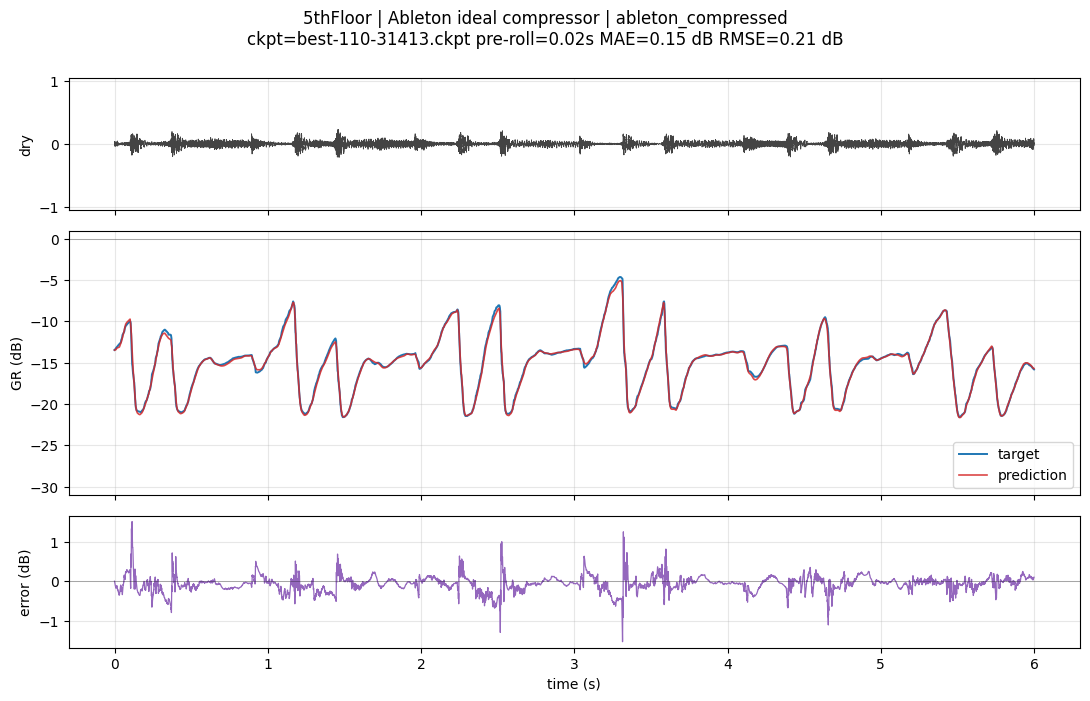

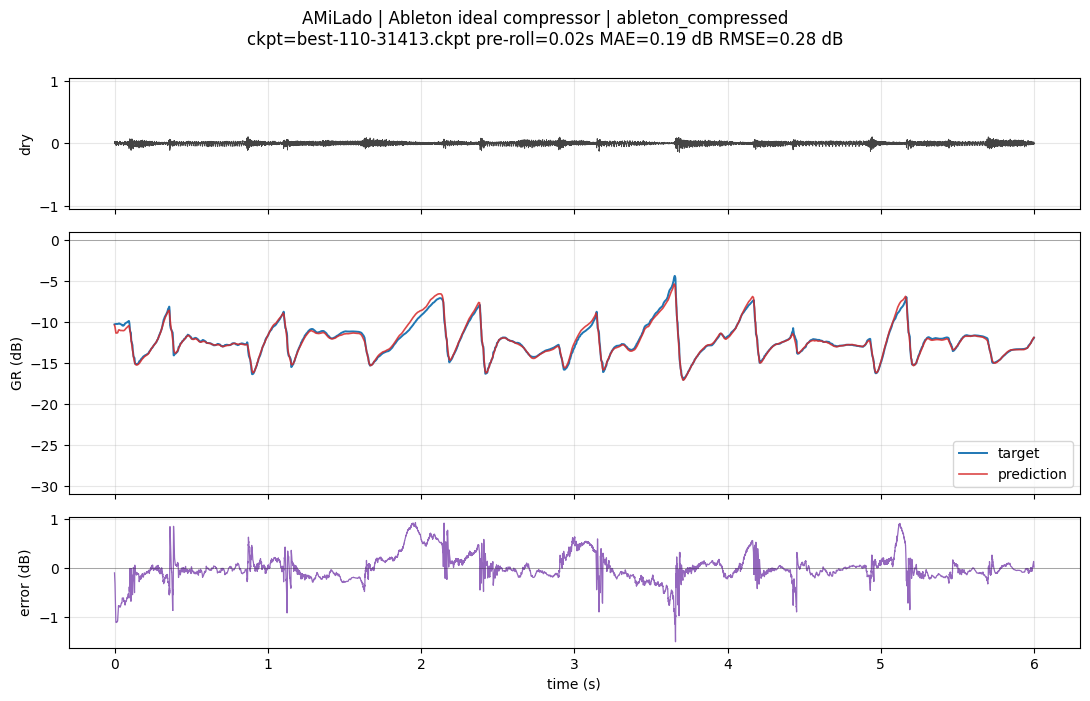

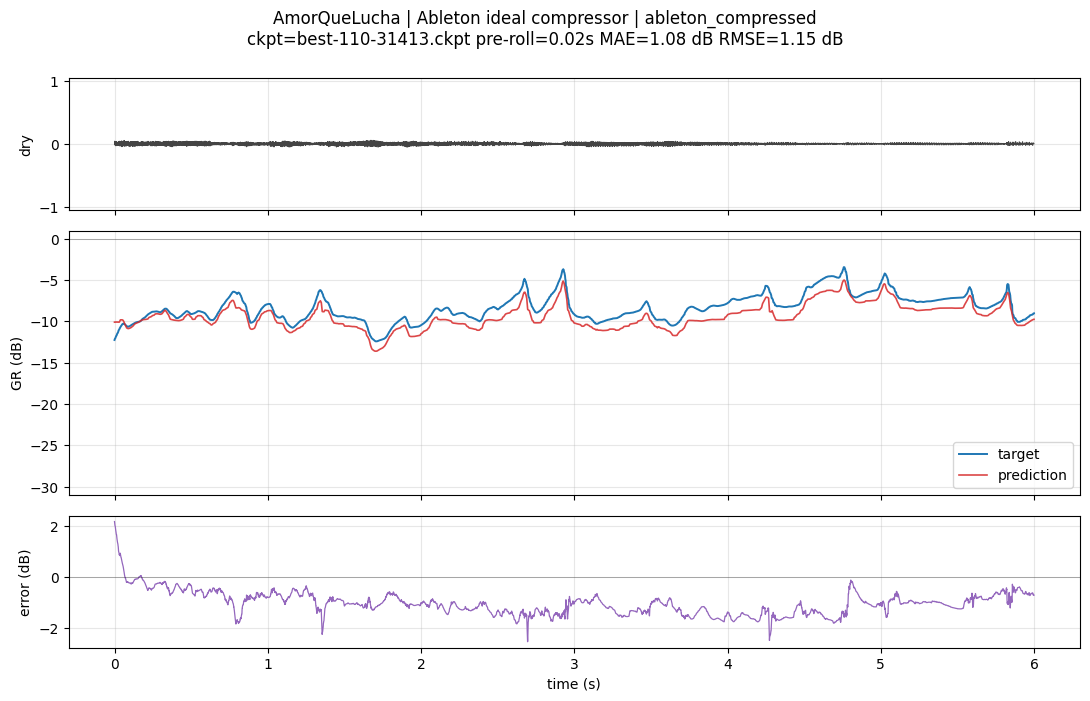

,song,mae_db,rmse_db,duration_sec,ckpt
0,5thFloor,0.145867,0.206484,6.0,best-110-31413.ckpt
1,AMiLado,0.189714,0.275626,6.0,best-110-31413.ckpt
2,AmorQueLucha,1.080230,1.154171,6.0,best-110-31413.ckpt


In [7]:
# Compare several songs
results = compare_same_setting_curves(
    ckpt_path=EVAL_CKPT_PATH,
    start_sec=20.0,
    duration_sec=6.0,
    max_pairs=3,
    start_pair=0,
    show_heatmap=False,
)

pd.DataFrame([
    {
        "song": r["song"],
        "mae_db": r["mae_db"],
        "rmse_db": r["rmse_db"],
        "duration_sec": r["duration_sec"],
        "ckpt": os.path.basename(r["ckpt"]),
    }
    for r in results
])


In [8]:
# Validation-set reconstructed audio metrics (chunked, memory-friendly)
#
# Reconstructs the same song-level validation split used during training,
# predicts GR in chunks, reconstructs wet audio as dry * 10 ** (GR_dB / 20),
# computes metrics per chunk, then reports one duration-weighted validation row.

import gc

from src.losses import compute_all_losses as compute_audio_losses


def _db_to_amplitude(db: torch.Tensor) -> torch.Tensor:
    return torch.pow(10.0, db / 20.0)


@torch.no_grad()
def _predict_segment_gr(
    system,
    dry_context: torch.Tensor,
    context_offset: int,
    target_len: int,
    device: torch.device,
) -> torch.Tensor:
    if hasattr(system.model, "reset_states"):
        system.model.reset_states()

    x = dry_context.unsqueeze(0).to(device)
    with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
        logits = system(x)
        gr_context_db = system.model.to_db(logits, T=dry_context.shape[-1])
        gr_context_db = gr_context_db.clamp(GR_DB_MIN, GR_DB_MAX)

    start = context_offset
    stop = context_offset + target_len
    return gr_context_db.squeeze(0)[..., start:stop].float().cpu()


def _pair_num_frames(dry_path: str, wet_path: str, sr: int) -> int:
    dry_info = sf.info(dry_path)
    wet_info = sf.info(wet_path)
    if dry_info.samplerate != sr or wet_info.samplerate != sr:
        print(
            f"[warning] {Path(dry_path).stem}: expected {sr} Hz, "
            f"got dry={dry_info.samplerate}, wet={wet_info.samplerate}; "
            "segment offsets assume matching sample rates."
        )
    return min(dry_info.frames, wet_info.frames)


def _song_from_dry_path(dry_path: str) -> str:
    return os.path.basename(dry_path).replace("_UnmasteredWAV.wav", "")


def _validation_pairs_from_training_split(
    all_pairs: list[tuple[str, str]],
    hp: dict,
) -> list[tuple[str, str]]:
    songs = sorted({_song_from_dry_path(dry_path) for dry_path, _ in all_pairs})
    split_seed = int(hp.get("split_seed", 42))
    train_split = float(hp.get("train_split", 0.8))

    generator = torch.Generator().manual_seed(split_seed)
    perm = torch.randperm(len(songs), generator=generator).tolist()
    n_train = int(len(songs) * train_split)
    n_train = min(max(1, n_train), len(songs) - 1)

    train_songs = {songs[i] for i in perm[:n_train]}
    val_songs = set(songs) - train_songs

    print(
        f"Validation split: {len(val_songs)} validation songs, "
        f"{len(train_songs)} train songs (seed={split_seed}, train_split={train_split})"
    )
    print(f"Validation songs: {sorted(val_songs)}")

    return [
        (dry_path, wet_path)
        for dry_path, wet_path in all_pairs
        if _song_from_dry_path(dry_path) in val_songs
    ]


from eval_helpers import (
    _db_to_amplitude,
    _pair_num_frames,
    _song_from_dry_path,
    _validation_pairs_from_training_split,
    _weighted_average_metric_rows,
)


# Leave as None to evaluate the full validation split. Use a small integer for
# a quick smoke test, or list validation song names for a subset.
MAX_VALIDATION_SONGS: int | None = None
EVAL_VALIDATION_SONGS: list[str] | None = None

# Smaller chunks reduce peak memory. Increase if you want faster evaluation and
# have RAM/VRAM headroom. Pre-roll gives the LSTM context before each chunk.
WHOLE_SONG_CHUNK_SEC = 10.0
WHOLE_SONG_PRE_ROLL_SEC = 2.0
SAVE_CHUNK_METRICS = False

system, hp = load_system_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
sr = int(hp["sample_rate"])
device = torch.device(DEVICE)
chunk_frames = int(round(WHOLE_SONG_CHUNK_SEC * sr))
pre_roll_frames = int(round(WHOLE_SONG_PRE_ROLL_SEC * sr))
metric_cols = ["MAE (L1)", "MSE (L2)", "ESR", "MR-STFT", "EDC", "M_NRMSE", "M_SF"]

all_pairs = same_setting_pairs(DATA_ROOT, hp.get("setting", SETTING))
eval_pairs = _validation_pairs_from_training_split(all_pairs, hp)

if EVAL_VALIDATION_SONGS is not None:
    selected_names = set(EVAL_VALIDATION_SONGS)
    eval_pairs = [
        (dry_path, wet_path)
        for dry_path, wet_path in eval_pairs
        if _song_from_dry_path(dry_path) in selected_names
    ]

if MAX_VALIDATION_SONGS is not None:
    eval_pairs = eval_pairs[:MAX_VALIDATION_SONGS]

assert eval_pairs, "No validation pairs selected for evaluation."

validation_chunk_rows = []
for song_idx, (dry_path, wet_path) in enumerate(eval_pairs, start=1):
    song = _song_from_dry_path(dry_path)
    total_frames = _pair_num_frames(dry_path, wet_path, sr)
    print(
        f"[{song_idx}/{len(eval_pairs)}] Evaluating validation song {song} "
        f"({total_frames / sr:.1f}s, chunks of {WHOLE_SONG_CHUNK_SEC:.1f}s)"
    )

    for chunk_idx, start in enumerate(range(0, total_frames, chunk_frames), start=1):
        stop = min(start + chunk_frames, total_frames)
        context_start = max(0, start - pre_roll_frames)
        context_offset = start - context_start

        dry_context, wet_context = _read_dry_wet_segment(
            dry_path,
            wet_path,
            context_start,
            stop,
            sr,
        )
        target_len = min(
            stop - start,
            dry_context.shape[-1] - context_offset,
            wet_context.shape[-1] - context_offset,
        )
        if target_len <= 0:
            continue

        dry_chunk = dry_context[..., context_offset : context_offset + target_len]
        wet_chunk = wet_context[..., context_offset : context_offset + target_len]
        gr_pred_db = _predict_segment_gr(
            system,
            dry_context,
            context_offset,
            target_len,
            device,
        )
        pred_wet = dry_chunk * _db_to_amplitude(gr_pred_db)

        losses = compute_audio_losses(pred_wet.unsqueeze(0), wet_chunk.unsqueeze(0))
        validation_chunk_rows.append({
            "Song": song,
            "Chunk": chunk_idx,
            "Start (s)": start / sr,
            "Duration (s)": target_len / sr,
            "Frames": target_len,
            **losses,
        })

        del dry_context, wet_context, dry_chunk, wet_chunk, gr_pred_db, pred_wet
        if device.type == "cuda":
            torch.cuda.empty_cache()

    gc.collect()

assert validation_chunk_rows, "No validation chunks were evaluated."

weighted_metrics = _weighted_average_metric_rows(validation_chunk_rows, metric_cols)
total_frames = sum(row["Frames"] for row in validation_chunk_rows)
validation_metrics_df = pd.DataFrame([
    {
        "Split": "validation",
        "Songs": len(eval_pairs),
        "Chunks": len(validation_chunk_rows),
        "Duration (s)": total_frames / sr,
        **weighted_metrics,
    }
])

validation_metrics_path = os.path.join(RUN_DIR, "eval_audio_metrics_validation.csv")
validation_metrics_df.to_csv(validation_metrics_path, index=False)
print(f"Saved validation audio metrics -> {validation_metrics_path}")

if SAVE_CHUNK_METRICS:
    chunk_metrics_path = os.path.join(RUN_DIR, "eval_audio_metrics_validation_chunks.csv")
    pd.DataFrame(validation_chunk_rows).to_csv(chunk_metrics_path, index=False)
    print(f"Saved validation chunk audio metrics -> {chunk_metrics_path}")

display(validation_metrics_df)

Validation split: 12 validation songs, 48 train songs (seed=42, train_split=0.8)
Validation songs: ['ALittleLate', 'APictureOfShit', 'AReasonToLeave', 'ASailorOnceMore', 'AccessDenied', 'AmorQueLucha', 'AnotherLife', 'AnotherLife2', 'Attention', 'Bankroll', 'CanYouSayTheSame', 'CatchTheWave']
[1/12] Evaluating validation song AmorQueLucha (282.5s, chunks of 10.0s)
[2/12] Evaluating validation song AnotherLife (293.7s, chunks of 10.0s)
[3/12] Evaluating validation song AnotherLife2 (241.8s, chunks of 10.0s)
[4/12] Evaluating validation song APictureOfShit (298.0s, chunks of 10.0s)
[5/12] Evaluating validation song AReasonToLeave (258.2s, chunks of 10.0s)
[6/12] Evaluating validation song ASailorOnceMore (208.0s, chunks of 10.0s)
[7/12] Evaluating validation song Attention (203.3s, chunks of 10.0s)
[8/12] Evaluating validation song Bankroll (227.8s, chunks of 10.0s)
[9/12] Evaluating validation song AccessDenied (292.3s, chunks of 10.0s)
[10/12] Evaluating validation song CanYouSayTheSam

,Split,Songs,Chunks,Duration (s),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,validation,12,305,2997.15102,0.000214,2.447429e-07,0.012815,0.06102,0.116483,0.092125,0.081792
